<a href="https://colab.research.google.com/github/Ashishpathak78/DL_practice/blob/main/DL_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1**

In [ ]:
import numpy as np

def step(x):
  return 1 if x>=0 else 0

class Perceptron:

  def __init__(self,weights,bias):
    self.weights = weights
    self.bias = bias

  def predict(self,inputs):
    total = np.dot(self.weights,inputs)+self.bias
    return step(total)


and_gate = Perceptron(np.array([1, 1]), -1.5)
or_gate = Perceptron(np.array([1, 1]), -0.5)

for x in [[0,0],[0,1],[1,0],[1,1]]:
  print(and_gate.predict(x))


for x in [[0,0],[0,1],[1,0],[1,1]]:
  print(or_gate.predict(x))

0
0
0
1
0
1
1
1


**2**

In [ ]:
class Perceptron:
  def __init__(self,learning_rate=0.1,epochs=100):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.weights = None
    self.bias = None

  def step_function(self,x):
    return 1 if x>=0 else 0

  def fit(self,X,y):
    n_samples,n_features = X.shape
    self.weights = np.zeros(n_features)
    self.bias = 0
    for _ in range(self.epochs):
      for i in range(n_samples):
        total = np.dot(self.weights,X[i])+self.bias
        y_pred = self.step_function(total)
        update = self.learning_rate*(y[i]-y_pred)
        self.weights+=update*X[i]
        self.bias += update
  def predict(self,inputs):
    linear_output = np.dot(self.weights,inputs)+self.bias
    return self.step_function(linear_output)

p1 = Perceptron()
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])
p1.fit(X,y)

for i in X:
  print(p1.predict(i))

1
1
0
0


Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XOR_XNOR_Network:
    def __init__(self):
        # Hidden layer weights
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        self.w_nand = np.array([-1, -1])
        self.b_nand = 1.5

        # Output layer weights (for XOR)
        self.w_out = np.array([1, 1])
        self.b_out = -1.5

    def predict_xor(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)      # OR
        h2 = step(np.dot(self.w_nand, x) + self.b_nand)  # NAND
        return step(h1 + h2 + self.b_out)

    def predict_xnor(self, x):
        return 1 - self.predict_xor(x)  # NOT XOR

network = XOR_XNOR_Network()

print("XOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
    print(x, "->", network.predict_xor(np.array(x)))

print("\nXNOR Gate")
for x in [(0,0),(0,1),(1,0),(1,1)]:
    print(x, "->", network.predict_xnor(np.array(x)))


XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


**4**

In [ ]:

def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)


p = Perceptron(weights=[1, 1], bias=-1)

test_inputs = [
    [0.49, 0.50],
    [0.50, 0.50],
    [0.51, 0.50]
]

for x in test_inputs:
    total = np.dot(p.weights, x) + p.bias
    print(f" Output:", p.predict(x))


 Output: 0
 Output: 1
 Output: 1


**5**

In [ ]:
# Perceptron Learning Algorithm
# Binary classification: Like (1) / Dislike (0) a movie

import numpy as np
import pandas as pd

# -----------------------------
# 1. Create dataset (CSV-like)
# -----------------------------
data = {
    "Matt_Damon": [1, 0, 0, 1, 0, 1],
    "Thriller":   [1, 1, 0, 0, 1, 0],
    "Nolan":      [0, 1, 0, 1, 1, 0],
    "IMDB":       [0.8, 0.9, 0.4, 0.7, 0.6, 0.3],
    "Like":       [1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
X = df[["Matt_Damon", "Thriller", "Nolan", "IMDB"]].values
y = df["Like"].values

# Step activation
def step(x):
    return 1 if x >= 0 else 0


# ---------------------------------------------------
# i) MP Perceptron (NO weights, NO bias)
# ---------------------------------------------------
class MPPerceptron:
    def predict(self, x):
        return step(np.sum(x))   # simple majority logic


mp = MPPerceptron()
print("MP Perceptron Predictions:")
for i, x in enumerate(X):
    print(f"Sample {i} → Pred: {mp.predict(x)}, Actual: {y[i]}")


# ---------------------------------------------------
# ii) Perceptron with WEIGHTS (NO bias)
# ---------------------------------------------------
class PerceptronNoBias:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.w = None

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for xi, yi in zip(X, y):
                y_pred = step(np.dot(self.w, xi))
                self.w += self.lr * (yi - y_pred) * xi

    def predict(self, x):
        return step(np.dot(self.w, x))


p_nb = PerceptronNoBias()
p_nb.fit(X, y)

print("\nPerceptron (Weights only):")
print("Weights:", p_nb.w)
for i, x in enumerate(X):
    print(f"Sample {i} → Pred: {p_nb.predict(x)}, Actual: {y[i]}")


# ---------------------------------------------------
# iii) Perceptron with WEIGHTS + BIAS
# ---------------------------------------------------
class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.epochs):
            for xi, yi in zip(X, y):
                y_pred = step(np.dot(self.w, xi) + self.b)
                update = self.lr * (yi - y_pred)
                self.w += update * xi
                self.b += update

    def predict(self, x):
        return step(np.dot(self.w, x) + self.b)


p = Perceptron()
p.fit(X, y)

print("\nPerceptron (Weights + Bias):")
print("Weights:", p.w)
print("Bias:", p.b)
for i, x in enumerate(X):
    print(f"Sample {i} → Pred: {p.predict(x)}, Actual: {y[i]}")


# ---------------------------------------------------
# Test with a NEW movie record
# ---------------------------------------------------
test_movie = np.array([1, 1, 0, 0.75])  # Matt Damon + Thriller, IMDb 7.5

print("\nTest Movie Prediction:")
print("MP Perceptron:", mp.predict(test_movie))
print("Perceptron (weights):", p_nb.predict(test_movie))
print("Perceptron (weights + bias):", p.predict(test_movie))


MP Perceptron Predictions:
Sample 0 → Pred: 1, Actual: 1
Sample 1 → Pred: 1, Actual: 1
Sample 2 → Pred: 1, Actual: 0
Sample 3 → Pred: 1, Actual: 1
Sample 4 → Pred: 1, Actual: 1
Sample 5 → Pred: 1, Actual: 0

Perceptron (Weights only):
Weights: [ 0.    0.1   0.1  -0.03]
Sample 0 → Pred: 1, Actual: 1
Sample 1 → Pred: 1, Actual: 1
Sample 2 → Pred: 0, Actual: 0
Sample 3 → Pred: 1, Actual: 1
Sample 4 → Pred: 1, Actual: 1
Sample 5 → Pred: 0, Actual: 0

Perceptron (Weights + Bias):
Weights: [0.  0.2 0.2 0.1]
Bias: -0.2
Sample 0 → Pred: 1, Actual: 1
Sample 1 → Pred: 1, Actual: 1
Sample 2 → Pred: 0, Actual: 0
Sample 3 → Pred: 1, Actual: 1
Sample 4 → Pred: 1, Actual: 1
Sample 5 → Pred: 0, Actual: 0

Test Movie Prediction:
MP Perceptron: 1
Perceptron (weights): 1
Perceptron (weights + bias): 1


**6**

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, lr=0.1, epochs=50):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            error = 0
            for xi, yi in zip(X, y):
                y_pred = step(np.dot(self.w, xi) + self.b)
                update = self.lr * (yi - y_pred)
                self.w += update * xi
                self.b += update
                error += abs(yi - y_pred)
            if error == 0:
                return True  # converged
        return False  # not converged


In [ ]:
# Inputs
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# All 16 Boolean functions
functions = [
    [0,0,0,0], [0,0,0,1], [0,0,1,0], [0,0,1,1],
    [0,1,0,0], [0,1,0,1], [0,1,1,0], [0,1,1,1],
    [1,0,0,0], [1,0,0,1], [1,0,1,0], [1,0,1,1],
    [1,1,0,0], [1,1,0,1], [1,1,1,0], [1,1,1,1]
]

not_learnable = []

for i, f in enumerate(functions):
    p = Perceptron()
    converged = p.fit(X, np.array(f))
    if not converged:
        not_learnable.append(i)

print("Functions NOT learned:", not_learnable)
print("Count:", len(not_learnable))


Functions NOT learned: [6, 9]
Count: 2


**7**

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

# Convert 0/1 to -1/+1
def bipolar(x):
    return -1 if x == 0 else 1

# Hidden layer perceptron
class HiddenPerceptron:
    def __init__(self, w, b):
        self.w = np.array(w)
        self.b = b

    def fire(self, x):
        return step(np.dot(self.w, x) + self.b)

# MLP Network
class BooleanMLP:
    def __init__(self, output_weights):
        self.hidden = [
            HiddenPerceptron([-1, -1], -2),  # (0,0)
            HiddenPerceptron([-1,  1], -2),  # (0,1)
            HiddenPerceptron([ 1, -1], -2),  # (1,0)
            HiddenPerceptron([ 1,  1], -2)   # (1,1)
        ]
        self.w_out = np.array(output_weights)
        self.b_out = -1

    def predict(self, x):
        x = np.array([bipolar(i) for i in x])
        h = np.array([hp.fire(x) for hp in self.hidden])
        y = step(np.dot(self.w_out, h) + self.b_out)
        return y


In [ ]:
# XOR weights
mlp = BooleanMLP(output_weights=[-1, 1, 1, -1])

inputs = [(0,0), (0,1), (1,0), (1,1)]
print("XOR Results:")
for x in inputs:
    print(x, "→", mlp.predict(x))


XOR Results:
(0, 0) → 0
(0, 1) → 1
(1, 0) → 1
(1, 1) → 0


**9**

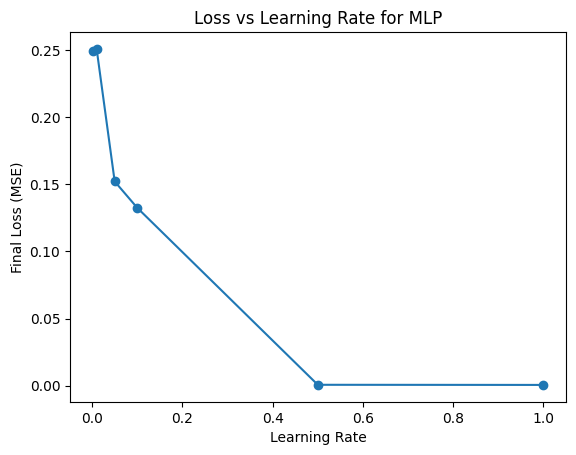

Learning Rate: 0.001 -> Final Loss: 0.2488
Learning Rate: 0.01 -> Final Loss: 0.2507
Learning Rate: 0.05 -> Final Loss: 0.1520
Learning Rate: 0.1 -> Final Loss: 0.1324
Learning Rate: 0.5 -> Final Loss: 0.0007
Learning Rate: 1.0 -> Final Loss: 0.0006


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset (XOR problem)
# -----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# MLP Class
# -----------------------------
class MLP:
    def __init__(self, learning_rate):
        self.lr = learning_rate
        self.w1 = np.random.randn(2, 2)
        self.b1 = np.random.randn(1, 2)
        self.w2 = np.random.randn(2, 1)
        self.b2 = np.random.randn(1, 1)

    def forward(self, X):
        self.h = sigmoid(np.dot(X, self.w1) + self.b1)
        self.out = sigmoid(np.dot(self.h, self.w2) + self.b2)
        return self.out

    def backward(self, X, y):
        error = y - self.out
        loss = np.mean(error ** 2)

        d_out = error * sigmoid_derivative(self.out)
        d_h = d_out.dot(self.w2.T) * sigmoid_derivative(self.h)

        self.w2 += self.h.T.dot(d_out) * self.lr
        self.b2 += np.sum(d_out, axis=0, keepdims=True) * self.lr
        self.w1 += X.T.dot(d_h) * self.lr
        self.b1 += np.sum(d_h, axis=0, keepdims=True) * self.lr

        return loss

# -----------------------------
# Experiment with Learning Rates
# -----------------------------
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []
epochs = 5000

for lr in learning_rates:
    model = MLP(lr)
    for _ in range(epochs):
        model.forward(X)
        loss = model.backward(X, y)
    final_losses.append(loss)

# -----------------------------
# Plot Loss vs Learning Rate
# -----------------------------
plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Loss vs Learning Rate for MLP")
plt.show()

# -----------------------------
# Print Results
# -----------------------------
for lr, loss in zip(learning_rates, final_losses):
    print(f"Learning Rate: {lr} -> Final Loss: {loss:.4f}")
